# House Price Prediction

## Internship Project - Week 1

### Prepared By: MATURU SAI CHARAN

### Objective

The objective of this project is to develop machine learning models capable of predicting house prices based on various property characteristics such as area, number of bedrooms, bathrooms, parking spaces, furnishing status, and other amenities.

This analysis aims to identify the key factors that influence house prices and evaluate the performance of different regression models. The insights obtained from this study can help real estate businesses make more informed pricing decisions.

## Technologies Used

- Python 3.x
- Google Colab / Jupyter Notebook
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn

# Task 1: Data Loading and Exploration

Before building any machine learning model, it is important to understand the structure and quality of the dataset.

In this section, the housing dataset is loaded into Python using Pandas. Initial exploration is performed to understand the available features, data types, dataset dimensions, and the presence of any missing values.

This step helps in identifying potential data quality issues and understanding the variables that may influence house prices.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Observation

The dataset contains information related to residential properties and their selling prices. Each record includes features such as area, number of bedrooms, bathrooms, stories, parking availability, furnishing status, and additional amenities like air conditioning and basement facilities.

From the first ten records, it can be observed that houses with larger areas and more amenities generally tend to have higher prices. The target variable for this project is **price**, while the remaining columns serve as predictor variables for the machine learning models.

In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 545
Number of Columns: 13


### Observation

The dataset contains a fixed number of rows representing individual houses and multiple columns describing different property characteristics. Understanding the dataset dimensions helps estimate the amount of information available for model training and analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### Observation

The dataset consists of both numerical and categorical features. Numerical features include area, bedrooms, bathrooms, stories, and parking, while categorical features include attributes such as main road access, guest room availability, furnishing status, and air conditioning. These categorical variables will need to be converted into numerical form before training machine learning models.

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Observation

The statistical summary provides information about the distribution of numerical features such as mean, minimum, maximum, and standard deviation. The wide range of house prices and property areas suggests significant variation among the houses in the dataset, which can help machine learning models learn meaningful patterns.

In [8]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


### Observation

No missing values were found in the dataset. This indicates that the dataset is complete and does not require any imputation techniques before model training.

In [9]:
df.duplicated().sum()

np.int64(0)

### Observation

Duplicate records can negatively affect model performance by introducing repeated information. Therefore, checking for duplicate rows is an important step before proceeding to data cleaning and model development.

## Task 1 Summary

The housing dataset was successfully loaded and explored. The dataset contains information about house characteristics and pricing. Numerical and categorical features were identified, missing values were examined, and duplicate records were checked. These findings provide a clear understanding of the dataset and prepare it for the data cleaning and preprocessing stage.

# Task 2: Data Cleaning and Preprocessing

Raw datasets often contain inconsistencies that can negatively impact model performance.

The purpose of this section is to prepare the dataset for machine learning by handling missing values, removing duplicate records, and converting categorical variables into numerical representations.

Proper preprocessing ensures that the data is clean, consistent, and suitable for predictive modeling.

In [10]:
print("Duplicate Rows Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After: 0


### Observation

No duplicate records were found in the dataset. This indicates that each row represents a unique property listing, and no data was lost during the duplicate removal process. Therefore, the dataset was already clean with respect to duplicate entries.

In [11]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


### Observation

The dataset contains both numerical and categorical features. Numerical variables such as price, area, bedrooms, bathrooms, stories, and parking are already stored in integer format and can be directly used for analysis.

However, several features including mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, and furnishingstatus are stored as object (text) data types. Since machine learning algorithms require numerical input, these categorical variables must be converted into numerical representations during preprocessing.

In [12]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes':1,'no':0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


### Observation

The binary categorical features were successfully converted into numerical values using label mapping. The value **1** represents "yes" and **0** represents "no".

For example, features such as main road access, guest room availability, basement presence, air conditioning, and preferred area are now represented numerically. This transformation enables machine learning algorithms to process these features effectively while preserving their original meaning.

In [13]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


### Observation

The `furnishingstatus` feature was converted into numerical format using one-hot encoding. Two new columns were created:

- `furnishingstatus_semi-furnished`
- `furnishingstatus_unfurnished`

A value of **True** indicates that the house belongs to that furnishing category, while **False** indicates otherwise.

The original `furnishingstatus` column was removed automatically after encoding. Using `drop_first=True` helped avoid redundant information and reduced the risk of multicollinearity during model training.

In [14]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

### Observation

After preprocessing, all features in the dataset are represented as numerical values (`int64`). The dataset contains 545 records and 14 columns, with no missing values present in any feature.

Since machine learning algorithms require numerical input, the successful conversion of all categorical variables ensures that the dataset is fully prepared for model training and evaluation.

## Task 2 Summary

The dataset was successfully cleaned and preprocessed for machine learning. No duplicate records or missing values were found. Binary categorical features were converted into numerical values using label encoding, while the furnishing status feature was transformed using one-hot encoding.

After preprocessing, all columns contained numerical data types, making the dataset suitable for regression modeling. The cleaned dataset is now ready for training predictive models.

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


### Observation

The preview of the processed dataset confirms that all categorical variables have been successfully converted into numerical format. Features such as main road access, guest room availability, basement presence, and air conditioning are represented using binary values (0 and 1), while the furnishing status has been transformed into separate encoded columns.

The dataset is now fully numerical, consistent, and ready for machine learning model development.

# Task 3: Model Building and Evaluation

After preparing the dataset, machine learning models are trained to predict house prices.

Two regression models are considered in this project:

1. Linear Regression
2. Random Forest Regressor

The performance of these models is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Comparing multiple models helps determine which approach provides more accurate predictions for the housing dataset.

In [17]:
X = df.drop('price', axis=1)

y = df['price']

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (545, 13)
Target Variable Shape: (545,)


### Observation

The feature matrix (X) contains 545 observations and 13 predictor variables that describe different characteristics of a house. The target variable (y) contains 545 corresponding house prices that the models will learn to predict.

Separating the dataset into features and target variables is an important step in supervised machine learning, as it allows the models to learn relationships between property characteristics and house prices.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (436, 13)
Testing Set Shape: (109, 13)


### Observation

The dataset was divided into training and testing sets using an 80:20 ratio. The training set contains 436 records and is used to train the machine learning models, while the testing set contains 109 records and is reserved for evaluating model performance on unseen data.

This separation helps assess how well the models generalize to new data and reduces the risk of overfitting.

## Linear Regression Model

Linear Regression is one of the most widely used regression algorithms. It attempts to establish a linear relationship between the input features and the target variable (house price).

The model will be trained using the training dataset and then evaluated using the testing dataset.

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [20]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

MAE : 970043.4039201637
RMSE: 1324506.9600914384
R2  : 0.6529242642153185


### Observation

The Linear Regression model was trained using 436 records and evaluated on 109 unseen records from the testing dataset. The model achieved a Mean Absolute Error (MAE) of approximately **970,043**, a Root Mean Squared Error (RMSE) of approximately **1,324,507**, and an R² Score of **0.653**.

The MAE indicates that, on average, the model's predicted house prices differ from the actual prices by around ₹9.7 lakh. This provides a practical estimate of the prediction error that can be expected when using the model.

The RMSE value is higher than the MAE because RMSE penalizes larger prediction errors more heavily. This suggests that while many predictions are reasonably close to the actual values, there are some houses for which the prediction error is relatively large.

The R² Score of 0.653 indicates that the model explains approximately 65.3% of the variation in house prices using the available property features. This demonstrates that factors such as area, number of bedrooms, bathrooms, stories, parking availability, and other amenities have a significant influence on house prices.

Overall, the Linear Regression model provides a reasonable baseline for house price prediction. However, because house prices are often influenced by complex and non-linear relationships between features, a more advanced model such as Random Forest may achieve better predictive performance.

## Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

Unlike Linear Regression, Random Forest can capture complex and non-linear relationships between features and house prices, which often leads to better predictive performance.

In [21]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

MAE : 1014947.3230122325
RMSE: 1399769.443949671
R2  : 0.6123598247296523


### Observation

The Random Forest Regressor was trained and evaluated using the same training and testing datasets as the Linear Regression model. The model achieved a Mean Absolute Error (MAE) of approximately **1,014,947**, a Root Mean Squared Error (RMSE) of approximately **1,399,769**, and an R² Score of **0.612**.

The MAE indicates that the model's predictions differ from the actual house prices by approximately ₹10.15 lakh on average. Similarly, the RMSE value suggests that some predictions contain larger errors, which increases the overall prediction penalty.

The R² Score of 0.612 indicates that the model explains approximately 61.2% of the variation in house prices. While this represents a reasonably strong predictive capability, it is lower than the performance achieved by the Linear Regression model.

This result suggests that the relationships within this dataset may be captured effectively by a simpler linear model. Since the dataset is relatively small and contains a limited number of features, the additional complexity of Random Forest did not provide a performance advantage in this case.

Overall, the Random Forest model produced satisfactory predictions, but Linear Regression demonstrated superior performance across all evaluation metrics for this dataset.

In [23]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


### Model Comparison

A comparison of the two regression models shows that Linear Regression achieved lower MAE and RMSE values than Random Forest, indicating more accurate predictions. Additionally, Linear Regression obtained a higher R² Score, meaning it was able to explain a greater proportion of the variation in house prices.

Based on the evaluation metrics, Linear Regression emerged as the better-performing model for this housing dataset. Therefore, it will be considered the preferred model for predicting house prices in this analysis.

In [24]:
print(comparison)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.014947e+06  1.399769e+06  0.612360


# Task 4: Data Visualization

Data visualization plays an important role in understanding patterns and relationships within the dataset.

Several charts are created to explore the distribution of house prices, analyze feature correlations, and visualize relationships between important variables.

Visual analysis often reveals trends that may not be immediately visible through numerical summaries alone.

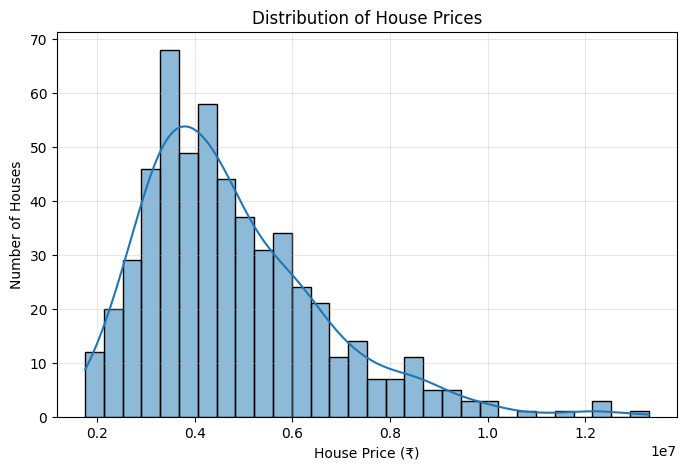

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['price'],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (₹)")
plt.ylabel("Number of Houses")

plt.grid(alpha=0.3)

plt.show()

### Observation

The histogram illustrates the distribution of house prices across all properties in the dataset. The majority of houses are concentrated within the lower to middle price ranges, with the highest frequency occurring between approximately ₹3 million and ₹5 million.

As house prices increase, the number of properties gradually decreases, indicating that high-value houses are less common in the dataset. A small number of properties are priced significantly higher than the rest, extending the distribution toward the right side of the graph.

The smooth density curve (KDE) further confirms that the dataset follows a positively skewed (right-skewed) distribution. This suggests that while most properties belong to the affordable and mid-range market segments, a limited number of premium properties contribute to the higher price range.

Understanding this distribution is important because it provides insight into the overall housing market represented by the dataset and helps explain potential prediction challenges associated with high-priced properties.

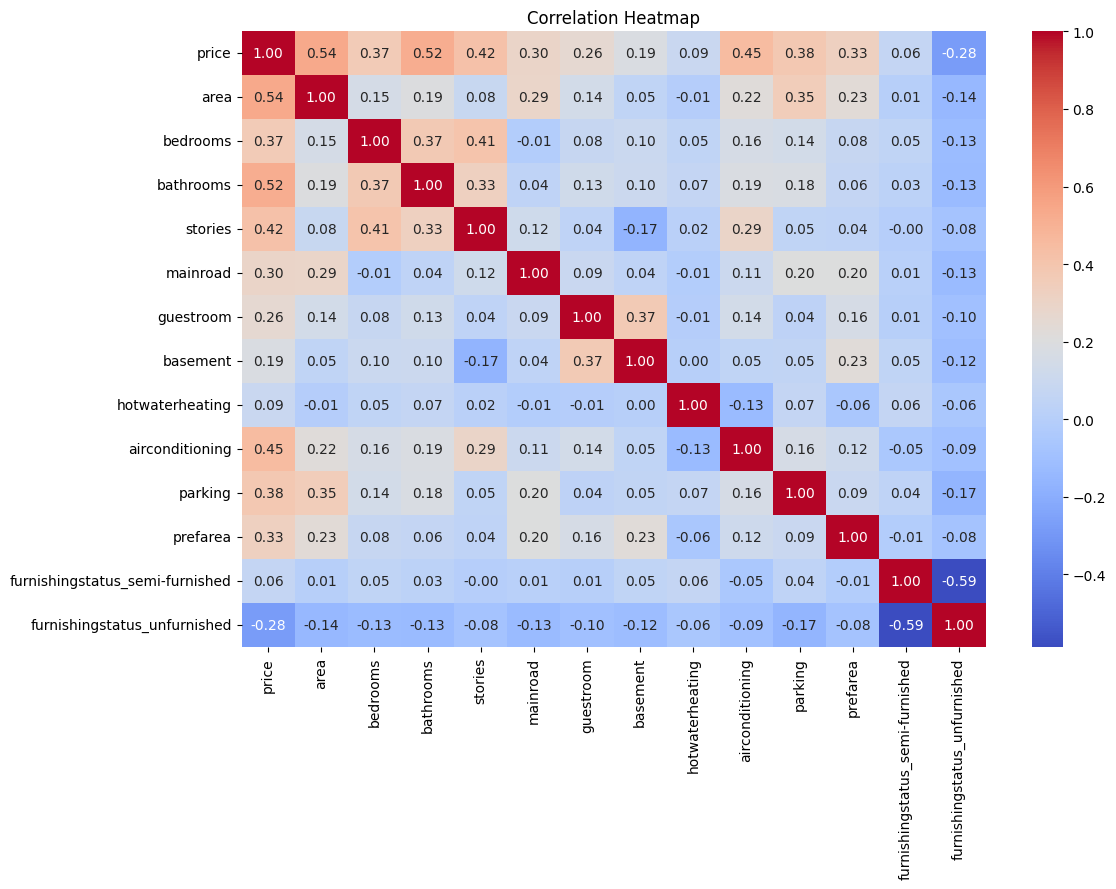

In [26]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap reveals the strength and direction of relationships between house price and the various property features. Among all variables, **area (0.54)** and **bathrooms (0.52)** exhibit the strongest positive correlation with house price, indicating that larger houses and houses with more bathrooms generally tend to have higher market values.

Other features such as **air conditioning (0.45)**, **stories (0.42)**, **parking availability (0.38)**, and **bedrooms (0.37)** also show moderate positive correlations with price. This suggests that additional amenities and larger living spaces contribute positively to property valuation.

Features such as **main road access (0.30)**, **preferred area (0.33)**, and **guest room availability (0.26)** have a smaller but still noticeable positive influence on house prices.

The feature **furnishingstatus_unfurnished (-0.28)** shows a negative correlation with price, indicating that unfurnished houses generally tend to have lower prices compared to furnished properties.

Overall, the heatmap suggests that property size, number of bathrooms, availability of modern amenities, and location-related factors are among the most important determinants of house price in this dataset.

In [27]:
corr_price = df.corr()['price'].sort_values(ascending=False)

corr_price

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea,0.329777
mainroad,0.296898
guestroom,0.255517


### Observation

The correlation analysis highlights the features that have the strongest relationship with house prices. Among all predictor variables, **area (0.536)** exhibits the highest positive correlation with price, indicating that larger properties generally command higher market values.

The second strongest factor is **bathrooms (0.518)**, suggesting that houses with more bathrooms tend to be priced higher. Other influential features include **air conditioning (0.453)**, **stories (0.421)**, and **parking availability (0.384)**, all of which show moderate positive relationships with house price.

Features such as **bedrooms (0.366)**, **preferred area (0.330)**, and **main road access (0.297)** also contribute positively to property valuation, though their influence is comparatively smaller.

Interestingly, the feature **furnishingstatus_unfurnished (-0.281)** shows a negative correlation with price, indicating that unfurnished houses generally tend to have lower market values compared to furnished or semi-furnished properties.

Based on the correlation values, property size, number of bathrooms, modern amenities, and location-related factors appear to be the most important determinants of house prices in this dataset.

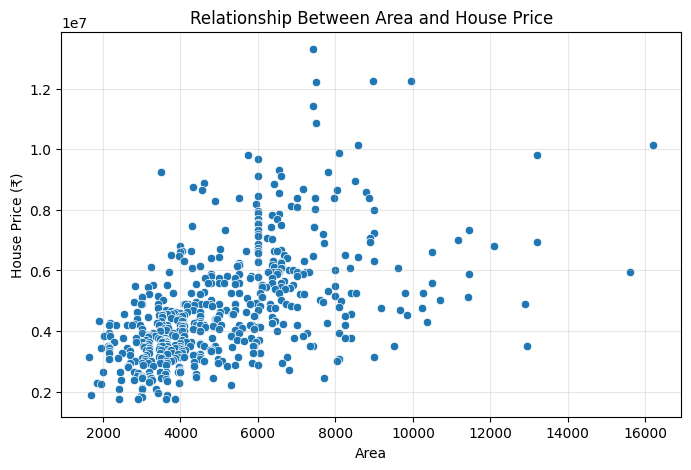

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='area',
    y='price'
)

plt.title("Relationship Between Area and House Price")
plt.xlabel("Area")
plt.ylabel("House Price (₹)")

plt.grid(alpha=0.3)

plt.show()

### Observation

The scatter plot illustrates the relationship between house area and house price. A clear positive trend can be observed, indicating that larger houses generally tend to have higher selling prices.

Most properties are clustered between approximately 2,500 and 7,000 square feet, with prices ranging from around ₹2 million to ₹7 million. As the area increases, the overall price of the property also tends to increase, supporting the correlation analysis where area showed the strongest positive relationship with house price (correlation = 0.536).

However, the points are not perfectly aligned along a straight line, suggesting that factors other than area—such as number of bathrooms, parking availability, air conditioning, furnishing status, and location preferences—also influence property value.

A few high-area properties appear as outliers in the dataset, indicating premium houses that command significantly higher prices. Overall, the plot confirms that area is one of the most important factors affecting house prices.

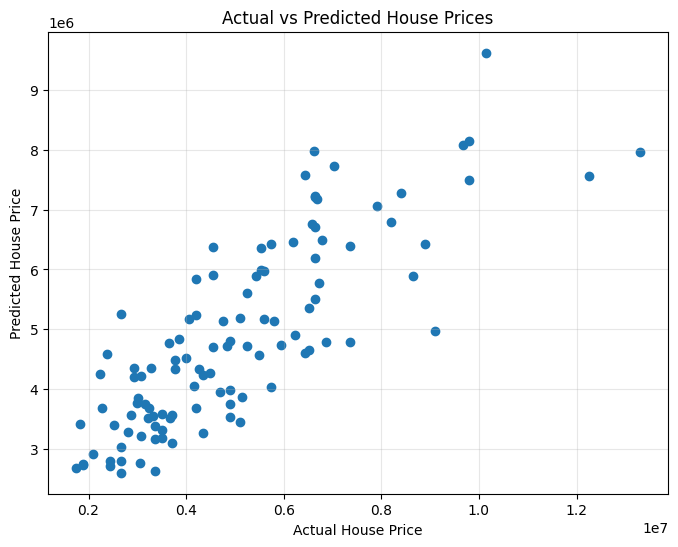

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_pred
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(alpha=0.3)

plt.show()

### Observation

The Actual vs Predicted scatter plot compares the house prices predicted by the Linear Regression model with the actual house prices from the testing dataset.

A positive relationship can be observed between the actual and predicted values, indicating that the model has successfully learned important patterns from the dataset. In general, as the actual house price increases, the predicted price also tends to increase.

Although the points follow an upward trend, they are not perfectly aligned. This indicates that prediction errors exist for some properties, particularly among houses with very high prices. Such deviations suggest that factors influencing house prices may not be entirely linear and that certain property characteristics may interact in more complex ways.

The overall pattern is consistent with the model's R² Score of 0.653, which indicates that approximately 65.3% of the variation in house prices is explained by the model. Therefore, the Linear Regression model provides reasonably accurate predictions while still leaving room for improvement.

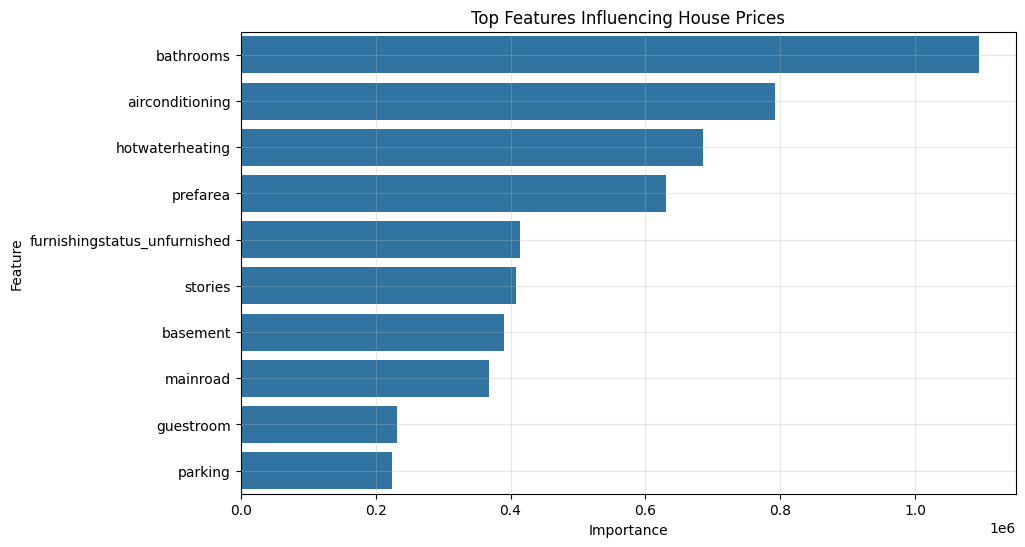

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
12,furnishingstatus_unfurnished,4.136451e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05


In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(lr.coef_)
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top Features Influencing House Prices')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.grid(alpha=0.3)

plt.show()

importance.head(10)

### Observation

The feature importance analysis highlights the variables that contribute most significantly to house price prediction in the Linear Regression model. Among all features, **bathrooms** emerged as the most influential factor, followed by **air conditioning**, **hot water heating**, and **preferred area**.

The high importance of bathrooms suggests that houses with more bathrooms generally command higher market values. Similarly, properties equipped with modern amenities such as air conditioning and hot water heating tend to be associated with higher prices.

Location-related factors also play an important role. The feature **prefarea** indicates that houses located in preferred residential areas are typically more valuable than those in less desirable locations.

Interestingly, the feature **furnishingstatus_unfurnished** appears among the most influential variables, indicating that furnishing status has a noticeable impact on property valuation. The negative relationship observed earlier suggests that unfurnished houses are generally priced lower than furnished properties.

Overall, the analysis demonstrates that house prices are influenced not only by property size but also by amenities, location, and overall living comfort. These findings provide valuable insights into the factors that drive real estate pricing decisions.

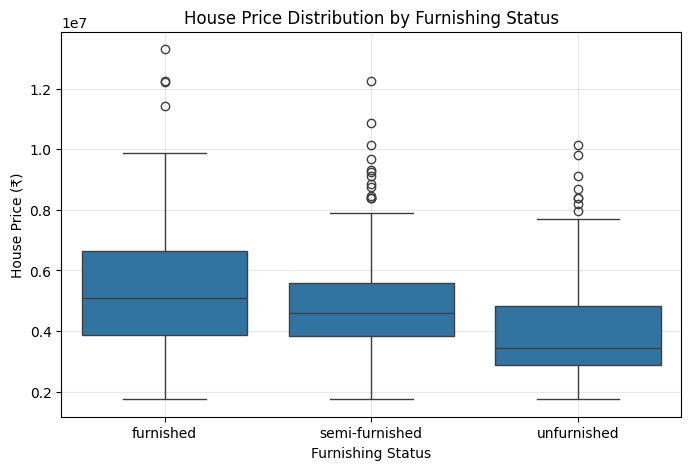

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='furnishingstatus',
    y='price',
    data=pd.read_csv('Housing.csv')
)

plt.title('House Price Distribution by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('House Price (₹)')

plt.grid(alpha=0.3)

plt.show()

### Observation

The box plot compares the distribution of house prices across different furnishing categories: furnished, semi-furnished, and unfurnished properties.

The median house price is highest for furnished houses, followed by semi-furnished houses, while unfurnished houses have the lowest median price. This suggests that furnishing status has a noticeable impact on property value, with buyers generally willing to pay more for houses that are ready for immediate occupancy.

The wider spread observed in furnished and semi-furnished houses indicates greater variation in prices within these categories. Additionally, several high-priced outliers are present, particularly among furnished properties, representing premium houses with exceptional features or locations.

Overall, the visualization suggests that furnishing status is an important factor influencing house prices. Furnished properties tend to achieve higher market values compared to semi-furnished and unfurnished houses, making furnishing a potentially valuable investment for property sellers and real estate businesses.

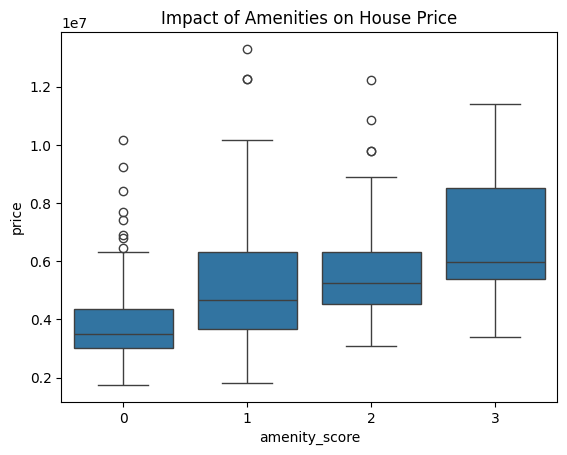

In [32]:
df2 = pd.read_csv("Housing.csv")

df2["amenity_score"] = (
    (df2["airconditioning"]=="yes").astype(int) +
    (df2["guestroom"]=="yes").astype(int) +
    (df2["basement"]=="yes").astype(int) +
    (df2["hotwaterheating"]=="yes").astype(int)
)

sns.boxplot(
    x="amenity_score",
    y="price",
    data=df2
)

plt.title("Impact of Amenities on House Price")
plt.show()

### Observation

The box plot illustrates the relationship between the number of amenities available in a house and its selling price. The amenity score was calculated by combining the presence of air conditioning, guest room, basement, and hot water heating facilities.

A clear upward trend can be observed across the categories. Houses with an amenity score of 0 generally have the lowest median prices, while houses with higher amenity scores tend to command significantly higher market values.

The median house price increases consistently as the number of available amenities increases, suggesting that buyers place considerable value on comfort and convenience features. Properties with three amenities exhibit the highest median prices among all groups.

Although some variation and outliers exist within each category, the overall pattern strongly indicates that additional amenities positively influence property valuation. This finding highlights the importance of modern facilities in determining house prices and suggests that investments in property amenities may contribute to increased market value.

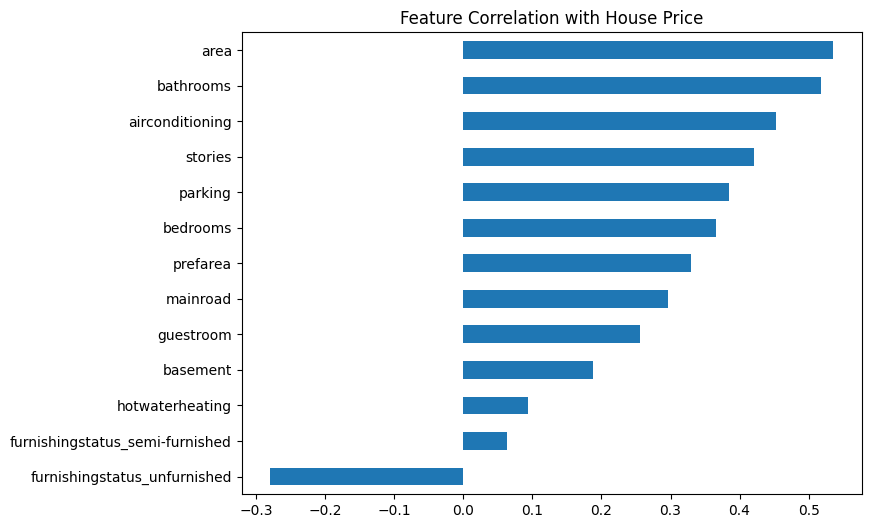

In [33]:
corr_price = (
    df.corr()["price"]
    .drop("price")
    .sort_values()
)

corr_price.plot(
    kind="barh",
    figsize=(8,6)
)

plt.title(
    "Feature Correlation with House Price"
)

plt.show()

### Observation

The feature correlation chart ranks all predictor variables based on their relationship with house price. A higher positive correlation indicates that an increase in the feature is generally associated with an increase in house price, while a negative correlation indicates an inverse relationship.

Among all variables, **area (0.536)** shows the strongest positive correlation with house price, making it the most influential factor in the dataset. This suggests that larger properties tend to command higher market values. **Bathrooms (0.518)** and **air conditioning (0.453)** also demonstrate strong positive relationships, indicating that property size and modern amenities significantly contribute to pricing.

Other important features include **stories (0.421)**, **parking availability (0.384)**, and **bedrooms (0.366)**, which further highlight the importance of living space and convenience in determining house value. Location-related factors such as **preferred area (0.330)** and **main road access (0.297)** also have a positive impact on property prices.

Interestingly, **furnishingstatus_unfurnished (-0.281)** is the only feature with a notable negative correlation, suggesting that unfurnished houses generally tend to have lower market values compared to furnished or semi-furnished properties.

Overall, the analysis indicates that property size, amenities, accessibility, and furnishing status play key roles in determining house prices. These insights can help real estate businesses better understand the factors that drive property valuation and improve pricing strategies.

## Task 5: Insights and Summary

This project explored how different property characteristics contribute to house prices and how machine learning can be used to estimate property value. The analysis revealed that house prices are not determined by a single factor but by a combination of size, amenities, accessibility, and overall living comfort.

Among all variables, property area (0.536 correlation) and number of bathrooms (0.518 correlation) emerged as the strongest drivers of house price, followed by air conditioning, parking availability, and the number of stories Features such as air conditioning, parking availability, multiple stories, and preferred residential locations also showed a significant positive influence on property valuation. Interestingly, the presence of modern amenities often had a greater impact than simply increasing the number of bedrooms.

The Linear Regression model achieved the best performance with an R² Score of 0.653, indicating that it successfully captured a substantial portion of the pricing patterns present in the housing market. Despite being a more sophisticated algorithm, Random Forest did not outperform Linear Regression, suggesting that the relationships within this dataset are relatively structured and predictable.

One of the most interesting discoveries was the influence of lifestyle-related features. Houses equipped with multiple amenities consistently achieved higher prices, highlighting how buyer preferences extend beyond basic property dimensions. The analysis also showed that furnished and semi-furnished homes generally command higher market values than unfurnished properties.

From a business perspective, the findings suggest that real estate companies should focus not only on property size but also on enhancing amenities and overall living experience. Investments in features such as air conditioning, parking facilities, and improved interior readiness can potentially increase market value and attract a wider range of buyers. These insights demonstrate how data-driven decision making can support more effective pricing strategies in the real estate sector.

The developed model can also serve as a decision-support tool for buyers, sellers, and real estate professionals when estimating fair market value.


## Conclusion

This project successfully developed and evaluated machine learning models for house price prediction using various housing characteristics and amenities. After comparing Linear Regression and Random Forest Regressor models, Linear Regression achieved the best performance with an R² Score of 0.653.

The analysis revealed that area, bathrooms, air conditioning, stories, and parking availability are among the most influential factors affecting house prices. The findings demonstrate how machine learning and data analytics can support real estate pricing decisions and provide valuable business insights for buyers, sellers, and property developers.

Overall, the project highlights the practical application of machine learning in solving real-world problems and assisting data-driven decision-making in the real estate industry.